Dataset: N=4, P=2, R=3, S=2
X =
 [[1. 2.]
 [2. 0.]
 [0. 1.]
 [1. 1.]]
Y =
 [[1. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]
 [0. 1. 0.]]

U = X @ B (latent coordinates):
 [[ 0.9 -0.5]
 [ 1.   0.2]
 [ 0.2 -0.3]
 [ 0.7 -0.2]]

Eta = U @ V.T + 1*m^T (linear predictors):
 [[ 0.9  -0.05 -1.  ]
 [ 1.    0.7  -0.96]
 [ 0.2  -0.2  -0.26]
 [ 0.7   0.15 -0.74]]

Pi = sigmoid(Eta) (predicted probabilities):
 [[0.7109 0.4875 0.2689]
 [0.7311 0.6682 0.2769]
 [0.5498 0.4502 0.4354]
 [0.6682 0.5374 0.323 ]]

Z = Eta + 4*(Y - Pi) (working response):
 [[ 2.0562 -2.     -2.0758]
 [ 2.0758  2.0272 -2.0675]
 [-1.9993 -2.0007 -2.0015]
 [-1.9728  2.0003 -2.032 ]]

m_new = column means of (Z - X B V^T):
 [-0.66   -0.1433 -1.3042]

A = Z - 1_N m_new^T (centered):
 [[ 2.7162 -1.8567 -0.7716]
 [ 2.7358  2.1705 -0.7633]
 [-1.3393 -1.8574 -0.6973]
 [-1.3127  2.1436 -0.7278]]
Column means (should be ~0): [ 0.7   0.15 -0.74]

(X^T X) =
 [[6. 3.]
 [3. 6.]]

(X^T X)^(-1/2) =
 [[ 0.4553 -0.122 ]
 [-0.122   0.4553]]

M = (X^T X)^(-

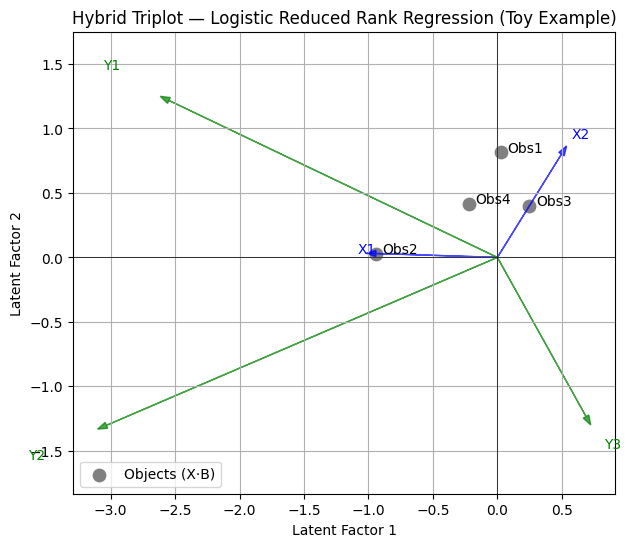

In [2]:
# ==============================================================
# Logistic Reduced Rank Regression (MM Algorithm)
# Detailed Walkthrough + Visualization (Toy Example)
# ==============================================================

import numpy as np
from scipy.special import expit as sigmoid
from numpy.linalg import svd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# --------------------------------------------------------------
# 1. Define Toy Data
# --------------------------------------------------------------
# N = 4 observations, P = 2 predictors, R = 3 binary outcomes
# S = 2 latent factors

X = np.array([[1,2],
              [2,0],
              [0,1],
              [1,1]], dtype=float)

Y = np.array([[1,0,0],
              [1,1,0],
              [0,0,0],
              [0,1,0]], dtype=float)

# Initial parameters
B = np.array([[0.5, 0.1],
              [0.2,-0.3]])  # P×S
V = np.array([[1.0, 0.0],
              [0.5, 1.0],
              [-1.0, 0.2]])  # R×S
m = np.zeros(3)  # intercepts

N, P = X.shape
R = Y.shape[1]
S = B.shape[1]

print(f"Dataset: N={N}, P={P}, R={R}, S={S}")
print("X =\n", X)
print("Y =\n", Y)

# --------------------------------------------------------------
# 2. Step 1 — Compute latent coordinates U = X @ B
# --------------------------------------------------------------
U = X @ B
print("\nU = X @ B (latent coordinates):\n", U)

# --------------------------------------------------------------
# 3. Step 2 — Compute linear predictors Eta = 1_N m^T + U @ V.T
# --------------------------------------------------------------
Eta = U @ V.T + np.outer(np.ones(N), m)
print("\nEta = U @ V.T + 1*m^T (linear predictors):\n", Eta)

# --------------------------------------------------------------
# 4. Step 3 — Compute probabilities Pi = sigmoid(Eta)
# --------------------------------------------------------------
Pi = sigmoid(Eta)
print("\nPi = sigmoid(Eta) (predicted probabilities):\n", Pi)

# --------------------------------------------------------------
# 5. Step 4 — Compute working response Z = Eta + 4*(Y - Pi)
# --------------------------------------------------------------
Z = Eta + 4*(Y - Pi)
print("\nZ = Eta + 4*(Y - Pi) (working response):\n", Z)

# --------------------------------------------------------------
# 6. Step 5 — Update intercepts m_new = mean(Z - X B V^T)
# --------------------------------------------------------------
residual_matrix = Z - (U @ V.T)
m_new = residual_matrix.mean(axis=0)
print("\nm_new = column means of (Z - X B V^T):\n", m_new)

# --------------------------------------------------------------
# 7. Step 6 — Center working responses A = Z - 1_N m_new^T
# --------------------------------------------------------------
A = Z - np.outer(np.ones(N), m_new)
print("\nA = Z - 1_N m_new^T (centered):\n", A)
print("Column means (should be ~0):", A.mean(axis=0))

# --------------------------------------------------------------
# 8. Step 7 — Compute M = (X^T X)^(-1/2) X^T A
# --------------------------------------------------------------
XtX = X.T @ X
eigvals, eigvecs = np.linalg.eigh(XtX)
inv_sqrt = eigvecs @ np.diag(1.0/np.sqrt(eigvals)) @ eigvecs.T
M = inv_sqrt @ X.T @ A

print("\n(X^T X) =\n", XtX)
print("\n(X^T X)^(-1/2) =\n", inv_sqrt)
print("\nM = (X^T X)^(-1/2) X^T A:\n", M)

# --------------------------------------------------------------
# 9. Step 8 — SVD of M = P Σ Q^T, keep top S components
# --------------------------------------------------------------
U_M, svals, Vt_M = svd(M, full_matrices=False)
U_S = U_M[:, :S]
Sigma_S = np.diag(svals[:S])
Q_S = Vt_M.T[:, :S]

print("\nSingular values Σ:", svals)
print("\nU_S (left singular vectors):\n", U_S)
print("\nQ_S (right singular vectors):\n", Q_S)

# --------------------------------------------------------------
# 10. Step 9 — Update B and V (canonical SVD scaling)
# --------------------------------------------------------------
B_new = inv_sqrt @ U_S
V_new = Q_S @ Sigma_S

print("\nUpdated B (P x S):\n", B_new)
print("\nUpdated V (R x S):\n", V_new)

# --------------------------------------------------------------
# 11. Step 10 — Recompute Eta_new and check deviance improvement
# --------------------------------------------------------------
def deviance(Y, P):
    eps = 1e-10
    return -2 * np.sum(Y * np.log(P + eps) + (1 - Y) * np.log(1 - P + eps))

Eta_new = X @ B_new @ V_new.T + np.outer(np.ones(N), m_new)
Pi_new = sigmoid(Eta_new)

dev_old = deviance(Y, Pi)
dev_new = deviance(Y, Pi_new)
print("\nOld deviance:", dev_old)
print("New deviance after SVD update:", dev_new)
print("\nA decrease (or no increase) shows MM step improved the surrogate fit.")

# --------------------------------------------------------------
# 12. Step 11 — Visualization: 2D Triplot of latent structure
# --------------------------------------------------------------
U_final = X @ B_new  # latent coordinates (N×S)

plt.figure(figsize=(7,6))

# Plot object points (U)
plt.scatter(U_final[:,0], U_final[:,1], color='gray', label='Objects (X·B)', s=80)
for i in range(U_final.shape[0]):
    plt.text(U_final[i,0]+0.05, U_final[i,1], f"Obs{i+1}", color='black')

# Predictor loadings (columns of B)
for j in range(B_new.shape[0]):
    plt.arrow(0, 0, B_new[j,0]*2, B_new[j,1]*2, color='blue',
              head_width=0.05, alpha=0.7)
    plt.text(B_new[j,0]*2.3, B_new[j,1]*2.3, f"X{j+1}", color='blue')

# Response loadings (rows of V)
for r in range(V_new.shape[0]):
    plt.arrow(0, 0, V_new[r,0], V_new[r,1], color='green',
              head_width=0.05, alpha=0.7)
    plt.text(V_new[r,0]*1.2, V_new[r,1]*1.2, f"Y{r+1}", color='green')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel("Latent Factor 1")
plt.ylabel("Latent Factor 2")
plt.title("Hybrid Triplot — Logistic Reduced Rank Regression (Toy Example)")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


Iter  1 | Deviance: 8.047023
Iter  2 | Deviance: 6.954406
Iter  3 | Deviance: 6.266089
Iter  4 | Deviance: 5.749825
Iter  5 | Deviance: 5.336236
Iter  6 | Deviance: 4.993832
Iter  7 | Deviance: 4.704555
Iter  8 | Deviance: 4.456496
Iter  9 | Deviance: 4.241149
Iter 10 | Deviance: 4.052178
Iter 11 | Deviance: 3.884749
Iter 12 | Deviance: 3.735120
Iter 13 | Deviance: 3.600363
Iter 14 | Deviance: 3.478155
Iter 15 | Deviance: 3.366640
Iter 16 | Deviance: 3.264313
Iter 17 | Deviance: 3.169946
Iter 18 | Deviance: 3.082526
Iter 19 | Deviance: 3.001208
Iter 20 | Deviance: 2.925283
Iter 21 | Deviance: 2.854153
Iter 22 | Deviance: 2.787307
Iter 23 | Deviance: 2.724307
Iter 24 | Deviance: 2.664776
Iter 25 | Deviance: 2.608388
Iter 26 | Deviance: 2.554855
Iter 27 | Deviance: 2.503930
Iter 28 | Deviance: 2.455392
Iter 29 | Deviance: 2.409047
Iter 30 | Deviance: 2.364723
Iter 31 | Deviance: 2.322267
Iter 32 | Deviance: 2.281541
Iter 33 | Deviance: 2.242423
Iter 34 | Deviance: 2.204803
Iter 35 | Devi

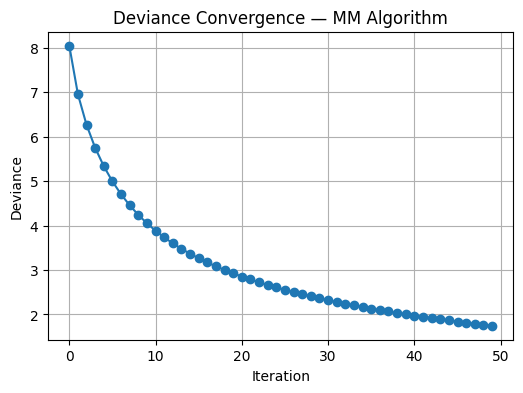


Final intercepts (m):
 [-7.9724  2.4608 -5.3333]

Final B (predictor loadings):
 [[-0.4455 -0.154 ]
 [ 0.0894  0.4629]]

Final V (response loadings):
 [[-14.1146   7.5155]
 [ -9.6    -11.0498]
 [ -0.0021   0.0018]]


In [3]:
# ==============================================================
# Iterative MM Algorithm for Logistic Reduced Rank Regression
# ==============================================================

def deviance(Y, P):
    """Compute model deviance (-2 * log-likelihood)."""
    eps = 1e-10
    return -2 * np.sum(Y * np.log(P + eps) + (1 - Y) * np.log(1 - P + eps))

def mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-6, verbose=True):
    """Majorization-Minimization algorithm for logistic reduced rank regression."""
    N, P = X.shape
    R = Y.shape[1]

    # Initialization
    np.random.seed(42)
    B = np.random.normal(0, 0.1, (P, S))
    V = np.random.normal(0, 0.1, (R, S))
    m = np.zeros(R)

    eigvals, eigvecs = np.linalg.eigh(X.T @ X)
    inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    dev_trace = []
    for it in range(max_iter):
        # Step 1: Linear predictor & probabilities
        Eta = np.outer(np.ones(N), m) + X @ B @ V.T
        Pi = sigmoid(Eta)

        # Step 2: Working response
        Z = Eta + 4 * (Y - Pi)

        # Step 3: Intercepts update
        m = np.mean(Z - X @ B @ V.T, axis=0)

        # Step 4: Center working responses
        A = Z - np.outer(np.ones(N), m)

        # Step 5: Whitened cross-covariance & SVD
        M = inv_sqrt @ X.T @ A
        U_M, svals, Vt_M = np.linalg.svd(M, full_matrices=False)
        U_S = U_M[:, :S]
        Sigma_S = np.diag(svals[:S])
        Q_S = Vt_M.T[:, :S]

        # Step 6: Parameter updates
        B = inv_sqrt @ U_S
        V = Q_S @ Sigma_S

        # Step 7: Compute deviance & convergence
        Eta_new = np.outer(np.ones(N), m) + X @ B @ V.T
        Pi_new = sigmoid(Eta_new)
        dev = deviance(Y, Pi_new)
        dev_trace.append(dev)

        if verbose:
            print(f"Iter {it+1:2d} | Deviance: {dev:.6f}")

        # Stop if improvement is small
        if it > 0 and abs(dev_trace[-2] - dev_trace[-1]) < tol:
            print("Converged after", it+1, "iterations.")
            break

    return {"B": B, "V": V, "m": m, "deviance": dev_trace, "Pi": Pi_new}

# --------------------------------------------------------------
# Run MM algorithm on toy dataset
# --------------------------------------------------------------
results = mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-8)

# --------------------------------------------------------------
# Plot deviance trace
# --------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(results["deviance"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Deviance")
plt.title("Deviance Convergence — MM Algorithm")
plt.grid(True)
plt.show()

# --------------------------------------------------------------
# Print final parameters
# --------------------------------------------------------------
print("\nFinal intercepts (m):\n", results["m"])
print("\nFinal B (predictor loadings):\n", results["B"])
print("\nFinal V (response loadings):\n", results["V"])


In [4]:
# ==============================================================
# Load and preprocess the Drug Consumption dataset
# ==============================================================

import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"
cols = ['ID','Age','Gender','Education','Country','Ethnicity',
        'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS'] + \
       ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc','Coke',
        'Crack','Ecstasy','Heroin','Ketamine','Legalh','LSD','Meth','Mushroom',
        'Nicotine','Semer','VSA']

df = pd.read_csv(url, header=None, names=cols)

print("Raw data shape:", df.shape)
print(df.head())

# 2. Convert drug usage categories CL0–CL6 to binary
def to_binary(val):
    return 1 if val in ['CL3','CL4','CL5','CL6'] else 0

drug_cols = ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc','Coke',
             'Crack','Ecstasy','Heroin','Ketamine','Legalh','LSD','Meth','Mushroom',
             'Nicotine','Semer','VSA']

for col in drug_cols:
    df[col] = df[col].apply(to_binary)

# 3. Predictor matrix X and response matrix Y
predictor_cols = ['Age','Gender','Education','Nscore','Escore','Oscore','Ascore',
                  'Cscore','Impulsive','SS']
X = df[predictor_cols].to_numpy(dtype=float)
Y = df[drug_cols].to_numpy(dtype=float)

print("Predictor shape (X):", X.shape)
print("Response shape (Y):", Y.shape)

# 4. Filter responses with prevalence between 0.1 and 0.9 (as in the R code)
col_means = Y.mean(axis=0)
mask = (col_means >= 0.1) & (col_means <= 0.9)
Y = Y[:, mask]
selected_drugs = [drug_cols[i] for i, keep in enumerate(mask) if keep]

print("Selected outcomes:", selected_drugs)
print("Filtered Y shape:", Y.shape)

# 5. Standardize predictors (mean 0, variance 1)
X = StandardScaler().fit_transform(X)


Raw data shape: (1885, 32)
   ID      Age   Gender  Education  Country  Ethnicity   Nscore   Escore  \
0   1  0.49788  0.48246   -0.05921  0.96082    0.12600  0.31287 -0.57545   
1   2 -0.07854 -0.48246    1.98437  0.96082   -0.31685 -0.67825  1.93886   
2   3  0.49788 -0.48246   -0.05921  0.96082   -0.31685 -0.46725  0.80523   
3   4 -0.95197  0.48246    1.16365  0.96082   -0.31685 -0.14882 -0.80615   
4   5  0.49788  0.48246    1.98437  0.96082   -0.31685  0.73545 -1.63340   

    Oscore   Ascore  ...  Ecstasy  Heroin  Ketamine Legalh  LSD Meth Mushroom  \
0 -0.58331 -0.91699  ...      CL0     CL0       CL0    CL0  CL0  CL0      CL0   
1  1.43533  0.76096  ...      CL4     CL0       CL2    CL0  CL2  CL3      CL0   
2 -0.84732 -1.62090  ...      CL0     CL0       CL0    CL0  CL0  CL0      CL1   
3 -0.01928  0.59042  ...      CL0     CL0       CL2    CL0  CL0  CL0      CL0   
4 -0.45174 -0.30172  ...      CL1     CL0       CL0    CL1  CL0  CL0      CL2   

  Nicotine Semer  VSA  
0    

Iter  1 | Deviance: 18972.046326
Iter  2 | Deviance: 18416.364901
Iter  3 | Deviance: 18222.345501
Iter  4 | Deviance: 18134.596801
Iter  5 | Deviance: 18089.375875
Iter  6 | Deviance: 18064.082576
Iter  7 | Deviance: 18049.094062
Iter  8 | Deviance: 18039.814274
Iter  9 | Deviance: 18033.865602
Iter 10 | Deviance: 18029.942515
Iter 11 | Deviance: 18027.293643
Iter 12 | Deviance: 18025.469528
Iter 13 | Deviance: 18024.192383
Iter 14 | Deviance: 18023.285621
Iter 15 | Deviance: 18022.634193
Iter 16 | Deviance: 18022.161516
Iter 17 | Deviance: 18021.815638
Iter 18 | Deviance: 18021.560731
Iter 19 | Deviance: 18021.371726
Iter 20 | Deviance: 18021.230859
Iter 21 | Deviance: 18021.125409
Iter 22 | Deviance: 18021.046173
Iter 23 | Deviance: 18020.986442
Iter 24 | Deviance: 18020.941290
Iter 25 | Deviance: 18020.907077
Iter 26 | Deviance: 18020.881100
Iter 27 | Deviance: 18020.861340
Iter 28 | Deviance: 18020.846287
Iter 29 | Deviance: 18020.834804
Iter 30 | Deviance: 18020.826034
Iter 31 | 

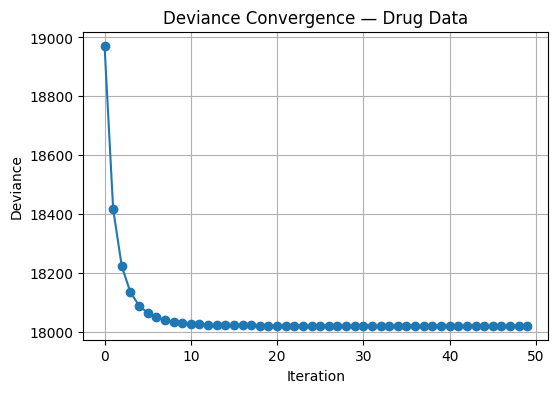


Final intercepts (m): [-1.5856 -1.0985  0.2161 -1.5173 -1.3479 -2.5205 -1.2946 -2.1372 -1.9611
 -1.7813  0.3152]

Final B shape: (10, 2)
Final V shape: (11, 2)


In [5]:
# --------------------------------------------------------------
# Fit logistic reduced rank model on drug data
# --------------------------------------------------------------

results_drugs = mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-6)

# Plot convergence
plt.figure(figsize=(6,4))
plt.plot(results_drugs["deviance"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Deviance")
plt.title("Deviance Convergence — Drug Data")
plt.grid(True)
plt.show()

# Print final parameter summaries
print("\nFinal intercepts (m):", results_drugs["m"])
print("\nFinal B shape:", results_drugs["B"].shape)
print("Final V shape:", results_drugs["V"].shape)


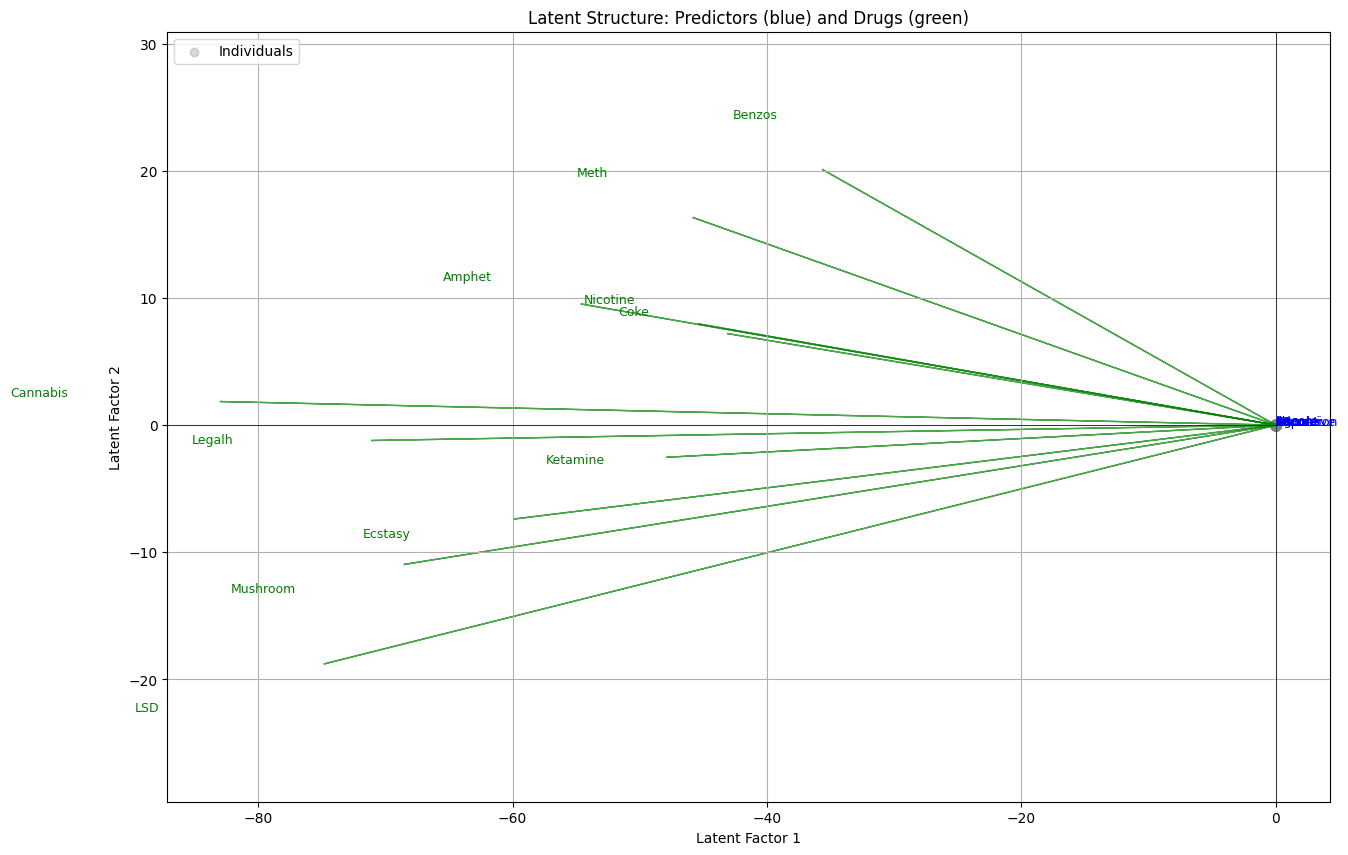

In [6]:
# --------------------------------------------------------------
# Visualization: Latent space for drug data
# --------------------------------------------------------------
B_drugs = results_drugs["B"]
V_drugs = results_drugs["V"]
U_drugs = X @ B_drugs

plt.figure(figsize=(15,10))

# Objects (individuals)
plt.scatter(U_drugs[:,0], U_drugs[:,1], color='gray', alpha=0.3, label='Individuals')

# Predictors (X)
for i, name in enumerate(predictor_cols):
    plt.arrow(0, 0, B_drugs[i,0]*2, B_drugs[i,1]*2, color='blue', head_width=0.05, alpha=0.7)
    plt.text(B_drugs[i,0]*2.2, B_drugs[i,1]*2.2, name, color='blue', fontsize=9)

# Responses (Y)
for j, name in enumerate(selected_drugs):
    plt.arrow(0, 0, V_drugs[j,0], V_drugs[j,1], color='green', head_width=0.05, alpha=0.7)
    plt.text(V_drugs[j,0]*1.2, V_drugs[j,1]*1.2, name, color='green', fontsize=9)

plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.title("Latent Structure: Predictors (blue) and Drugs (green)")
plt.xlabel("Latent Factor 1")
plt.ylabel("Latent Factor 2")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()



Quality of Representation (QoR) per response:

Amphet    : 0.193
Benzos    : 0.124
Cannabis  : 0.348
Coke      : 0.133
Ecstasy   : 0.224
Ketamine  : 0.135
Legalh    : 0.282
LSD       : 0.295
Meth      : 0.151
Mushroom  : 0.263
Nicotine  : 0.156


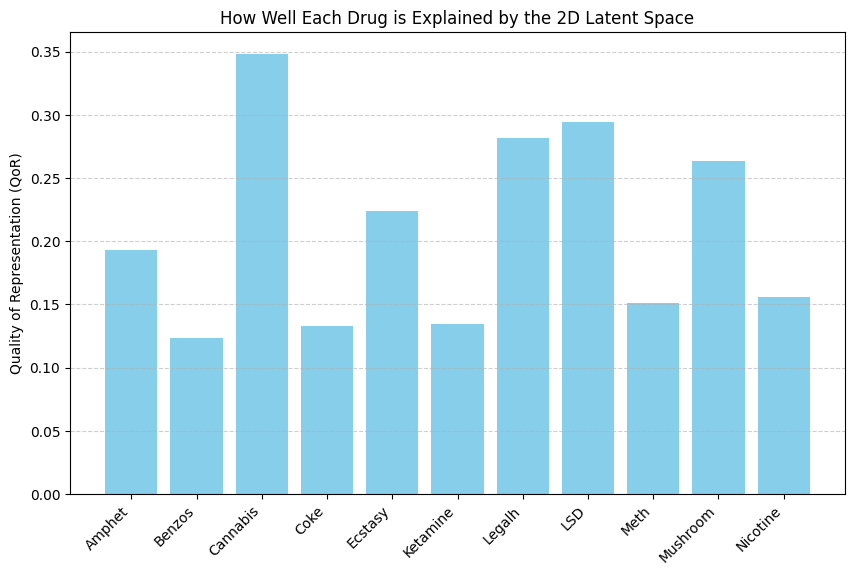

In [7]:
# ==============================================================
# Quality of Representation (QoR) for each response
# ==============================================================

def quality_of_representation(Y, Pi):
    """Compute Quality of Representation (QoR) for each response."""
    eps = 1e-10
    N, R = Y.shape
    QoR = np.zeros(R)

    for r in range(R):
        y = Y[:, r]
        pi = Pi[:, r]

        # 1. Null model (intercept only)
        p_null = np.mean(y)
        D_null = -2 * np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))

        # 2. Reduced rank model deviance
        D_model = -2 * np.sum(y * np.log(pi + eps) + (1 - y) * np.log(1 - pi + eps))

        # 3. Quality of representation
        QoR[r] = 1 - D_model / D_null

    return QoR

# --------------------------------------------------------------
# Compute QoR for each drug
# --------------------------------------------------------------
Pi_fitted = results_drugs["Pi"]
QoR_values = quality_of_representation(Y, Pi_fitted)

print("\nQuality of Representation (QoR) per response:\n")
for drug, q in zip(selected_drugs, QoR_values):
    print(f"{drug:10s}: {q:.3f}")

# --------------------------------------------------------------
# Plot QoR values
# --------------------------------------------------------------
plt.figure(figsize=(10,6))
plt.bar(selected_drugs, QoR_values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quality of Representation (QoR)")
plt.title("How Well Each Drug is Explained by the 2D Latent Space")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


Rank 0: Explained deviance = 0.0000
Rank 1: Explained deviance = 0.2057
Rank 2: Explained deviance = 0.2145
Rank 3: Explained deviance = 0.2195
Rank 4: Explained deviance = 0.2213
Rank 5: Explained deviance = 0.2218


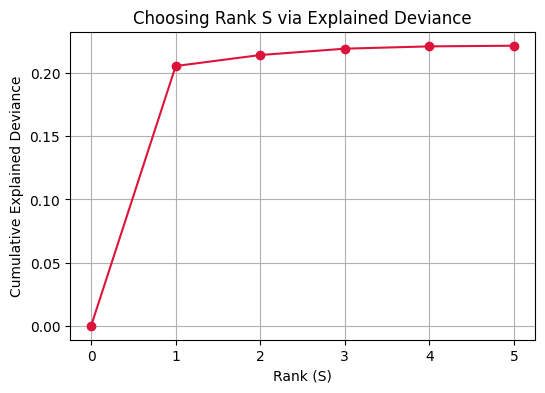

In [8]:
# ==============================================================
# Cumulative Explained Deviance (to choose number of factors S)
# ==============================================================

def explained_deviance_curve(X, Y, max_S=5, max_iter=50, tol=1e-6):
    """
    Fit logistic reduced rank regression models for S=0..max_S
    and compute cumulative explained deviance.
    """
    N, R = Y.shape

    # 1. Compute null deviance (intercept-only)
    eps = 1e-10
    p_null = Y.mean(axis=0)
    D_null = -2 * np.sum(Y * np.log(p_null + eps) + (1 - Y) * np.log(1 - p_null + eps))

    results = []
    for S in range(0, max_S + 1):
        if S == 0:
            D_model = D_null  # no latent factors
        else:
            res = mm_logistic_rrr(X, Y, S=S, max_iter=max_iter, tol=tol, verbose=False)
            D_model = res["deviance"][-1]
        explained = 1 - D_model / D_null
        results.append(explained)
        print(f"Rank {S}: Explained deviance = {explained:.4f}")

    return np.array(results)

# --------------------------------------------------------------
# Run explained deviance curve for ranks 0..5
# --------------------------------------------------------------
curve = explained_deviance_curve(X, Y, max_S=5, max_iter=40)

# --------------------------------------------------------------
# Plot explained deviance curve
# --------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(range(0, len(curve)), curve, marker='o', color='crimson')
plt.xlabel("Rank (S)")
plt.ylabel("Cumulative Explained Deviance")
plt.title("Choosing Rank S via Explained Deviance")
plt.grid(True)
plt.show()


In [9]:
B = results_drugs["B"]
V = results_drugs["V"]
m = results_drugs["m"]
U = X @ B

In [10]:
# ==============================================================
# Type I Triplot (inner-product interpretation)
# ==============================================================

def typeI_triplot(U, B, V, m, predictor_names, response_names, 
                  prob_levels=[0.1, 0.25, 0.5, 0.75, 0.9]):
    plt.figure(figsize=(8,6))

    # Objects
    plt.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        plt.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        plt.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue')

    # Responses (axes with probability ticks)
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        line_end = v * 3
        plt.plot([0, line_end[0]], [0, line_end[1]], 'g--', lw=1, alpha=0.8)
        for p in prob_levels:
            t = (np.log(p/(1-p)) - m[r]) / v_norm2
            tick = t * v
            plt.plot(tick[0], tick[1], 'go', markersize=3)
            if p == 0.5:
                plt.text(tick[0], tick[1], name, color='green', fontsize=9)

    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.title("Type I Triplot — Probability Axes")
    plt.xlabel("Latent Factor 1")
    plt.ylabel("Latent Factor 2")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.show()


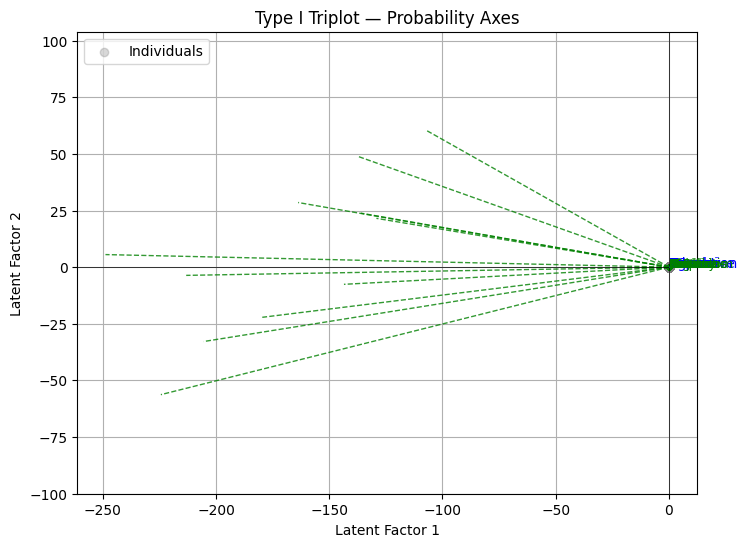

In [11]:
typeI_triplot(U, B, V, m, predictor_cols, selected_drugs)


In [12]:
# ==============================================================
# Type D Triplot (distance interpretation)
# ==============================================================

def typeD_triplot(U, B, V, m, predictor_names, response_names):
    plt.figure(figsize=(8,6))

    # Objects
    plt.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        plt.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        plt.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue')

    # Responses: category points
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        w_yes = (-m[r] / v_norm2) * v
        w_no = w_yes - (2 / v_norm2) * v
        plt.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], 'g-', lw=2)
        plt.text(w_yes[0], w_yes[1], f"{name}(1)", color='green')
        plt.text(w_no[0], w_no[1], f"{name}(0)", color='green')

    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.title("Type D Triplot — Category Endpoints")
    plt.xlabel("Latent Factor 1")
    plt.ylabel("Latent Factor 2")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.show()


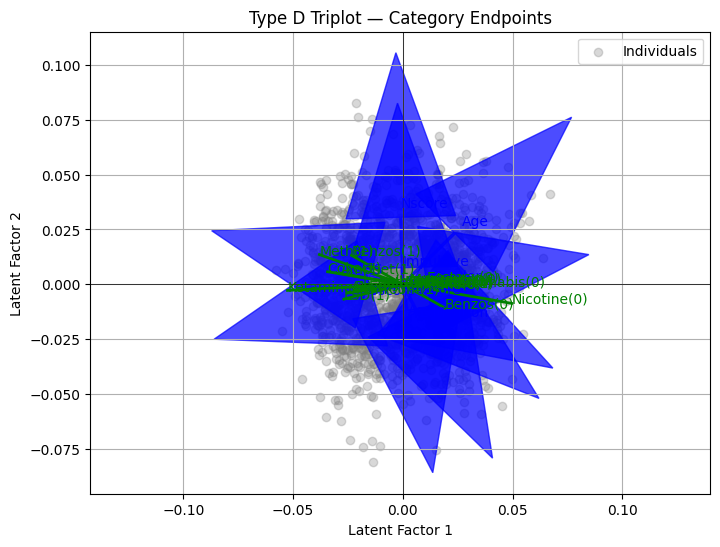

In [13]:
typeD_triplot(U, B, V, m, predictor_cols, selected_drugs)

In [14]:
# ==============================================================
# Hybrid Triplot (combined Type I + Type D)
# ==============================================================

def hybrid_triplot(U, B, V, m, predictor_names, response_names, prob_levels=[0.1, 0.5, 0.9]):
    plt.figure(figsize=(8,6))

    # Objects
    plt.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        plt.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        plt.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue')

    # Responses (hybrid axes)
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        # Dotted axis (Type I)
        line_end = v * 3
        plt.plot([0, line_end[0]], [0, line_end[1]], 'g--', lw=1, alpha=0.8)
        # Probability ticks
        for p in prob_levels:
            t = (np.log(p/(1-p)) - m[r]) / v_norm2
            tick = t * v
            plt.plot(tick[0], tick[1], 'go', markersize=3)
        # Category endpoints (Type D)
        w_yes = (-m[r] / v_norm2) * v
        w_no = w_yes - (2 / v_norm2) * v
        plt.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], 'g-', lw=2)
        plt.text(w_yes[0], w_yes[1], f"{name}(1)", color='green', fontsize=9)

    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.title("Hybrid Triplot — Combined Interpretation")
    plt.xlabel("Latent Factor 1")
    plt.ylabel("Latent Factor 2")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.show()


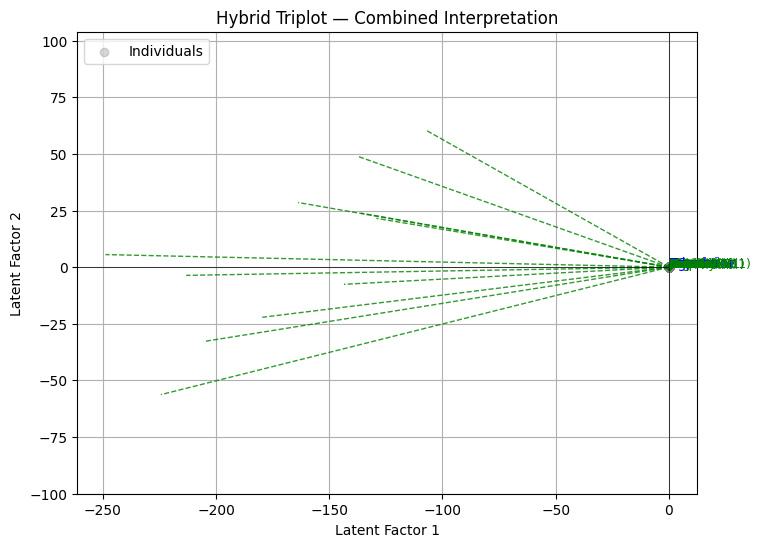

In [15]:
hybrid_triplot(U, B, V, m, predictor_cols, selected_drugs)


In [16]:
# ==============================================================
# Multi-panel Triplot Visualization (Type I, Type D, Hybrid)
# ==============================================================

import matplotlib.pyplot as plt
import numpy as np

def multi_triplot(U, B, V, m, predictor_names, response_names,
                  prob_levels=[0.1, 0.5, 0.9]):
    """Create a side-by-side plot with Type I, Type D, and Hybrid triplots."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ----------------------------------------------------------
    # Type I
    # ----------------------------------------------------------
    ax = axes[0]
    ax.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        ax.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        ax.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue', fontsize=8)

    # Responses
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        line_end = v * 3
        ax.plot([0, line_end[0]], [0, line_end[1]], 'g--', lw=1, alpha=0.8)
        for p in prob_levels:
            t = (np.log(p/(1-p)) - m[r]) / v_norm2
            tick = t * v
            ax.plot(tick[0], tick[1], 'go', markersize=2)
            if p == 0.5:
                ax.text(tick[0], tick[1], name, color='green', fontsize=8)

    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title("Type I — Probability Axes")
    ax.set_xlabel("Latent Factor 1")
    ax.set_ylabel("Latent Factor 2")
    ax.grid(True)
    ax.axis("equal")

    # ----------------------------------------------------------
    # Type D
    # ----------------------------------------------------------
    ax = axes[1]
    ax.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        ax.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        ax.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue', fontsize=8)

    # Responses — category endpoints
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        w_yes = (-m[r] / v_norm2) * v
        w_no = w_yes - (2 / v_norm2) * v
        ax.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], 'g-', lw=2)
        ax.text(w_yes[0], w_yes[1], f"{name}(1)", color='green', fontsize=8)
        ax.text(w_no[0], w_no[1], f"{name}(0)", color='green', fontsize=8)

    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title("Type D — Category Endpoints")
    ax.set_xlabel("Latent Factor 1")
    ax.set_ylabel("Latent Factor 2")
    ax.grid(True)
    ax.axis("equal")

    # ----------------------------------------------------------
    # Hybrid
    # ----------------------------------------------------------
    ax = axes[2]
    ax.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

    # Predictors
    for j, name in enumerate(predictor_names):
        ax.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
        ax.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue', fontsize=8)

    # Responses — hybrid representation
    for r, name in enumerate(response_names):
        v = V[r,:]
        v_norm2 = np.dot(v, v)
        line_end = v * 3
        ax.plot([0, line_end[0]], [0, line_end[1]], 'g--', lw=1, alpha=0.8)
        for p in prob_levels:
            t = (np.log(p/(1-p)) - m[r]) / v_norm2
            tick = t * v
            ax.plot(tick[0], tick[1], 'go', markersize=2)
        w_yes = (-m[r] / v_norm2) * v
        w_no = w_yes - (2 / v_norm2) * v
        ax.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], 'g-', lw=2)
        ax.text(w_yes[0], w_yes[1], f"{name}(1)", color='green', fontsize=8)

    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title("Hybrid — Combined View")
    ax.set_xlabel("Latent Factor 1")
    ax.set_ylabel("Latent Factor 2")
    ax.grid(True)
    ax.axis("equal")

    plt.tight_layout()
    plt.show()


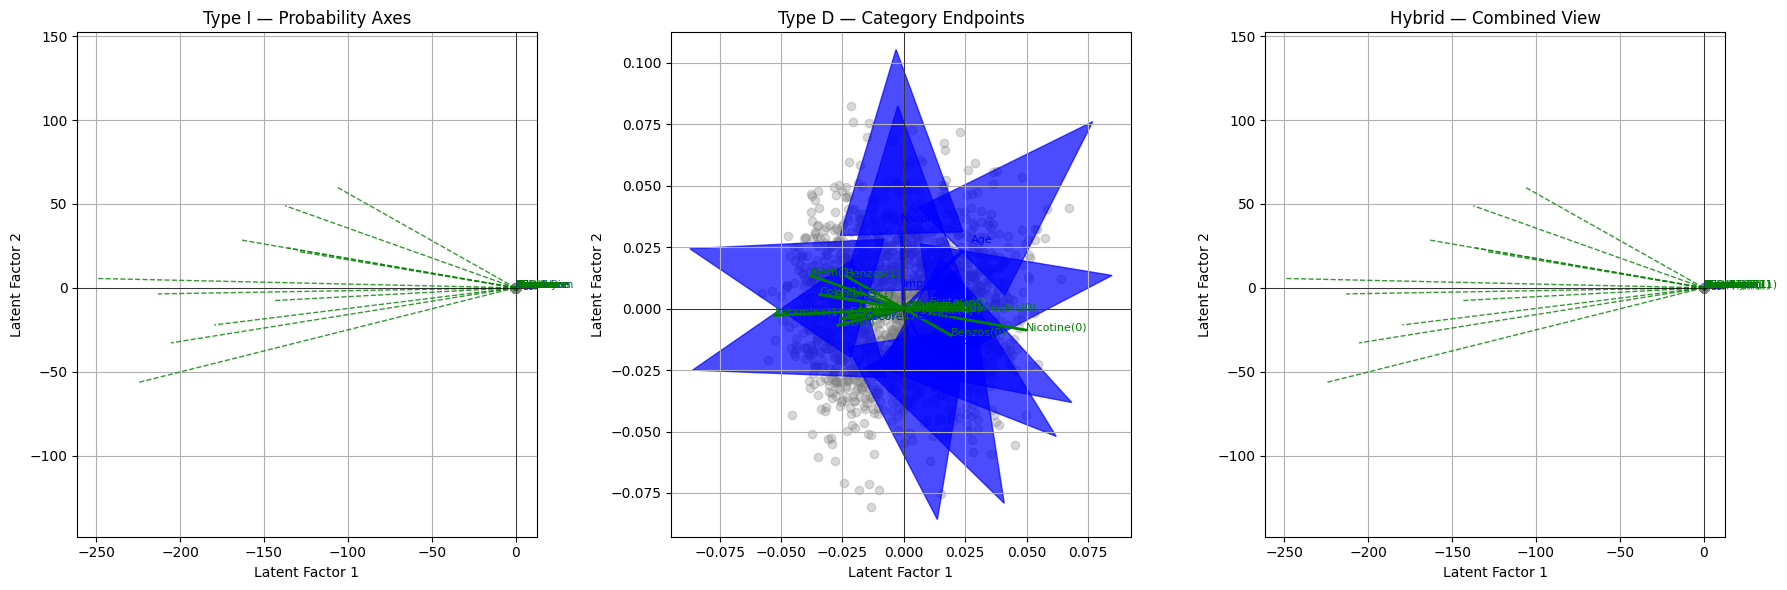

In [17]:
multi_triplot(U, B, V, m, predictor_cols, selected_drugs)


Raw dataset shape: (1885, 32)
Predictors shape (1885, 10), Responses shape (1885, 11)
Selected drug outcomes: ['Amphet', 'Benzos', 'Cannabis', 'Coke', 'Ecstasy', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushroom', 'Nicotine']
Iter  1: Deviance = 18972.046326
Iter  2: Deviance = 18416.364901
Iter  3: Deviance = 18222.345501
Iter  4: Deviance = 18134.596801
Iter  5: Deviance = 18089.375875
Iter  6: Deviance = 18064.082576
Iter  7: Deviance = 18049.094062
Iter  8: Deviance = 18039.814274
Iter  9: Deviance = 18033.865602
Iter 10: Deviance = 18029.942515
Iter 11: Deviance = 18027.293643
Iter 12: Deviance = 18025.469528
Iter 13: Deviance = 18024.192383
Iter 14: Deviance = 18023.285621
Iter 15: Deviance = 18022.634193
Iter 16: Deviance = 18022.161516
Iter 17: Deviance = 18021.815638
Iter 18: Deviance = 18021.560731
Iter 19: Deviance = 18021.371726
Iter 20: Deviance = 18021.230859
Iter 21: Deviance = 18021.125409
Iter 22: Deviance = 18021.046173
Iter 23: Deviance = 18020.986442
Iter 24: Deviance 

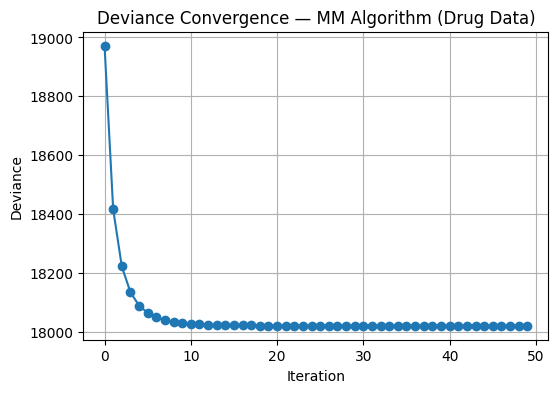

Final shapes: B (10, 2) V (11, 2)


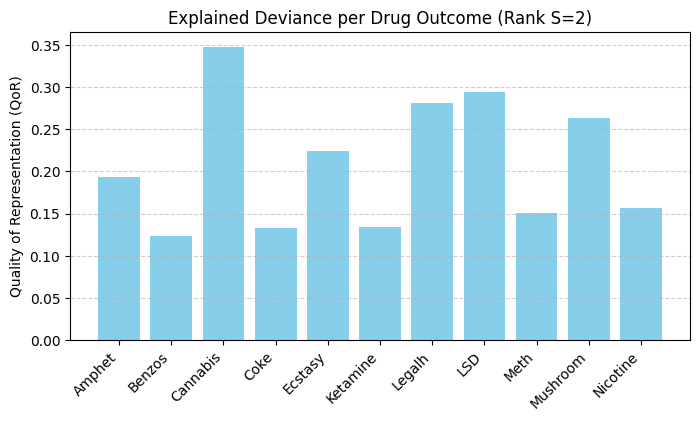

S=0: Explained deviance=0.0000
S=1: Explained deviance=0.2057
S=2: Explained deviance=0.2145
S=3: Explained deviance=0.2195
S=4: Explained deviance=0.2213
S=5: Explained deviance=0.2218


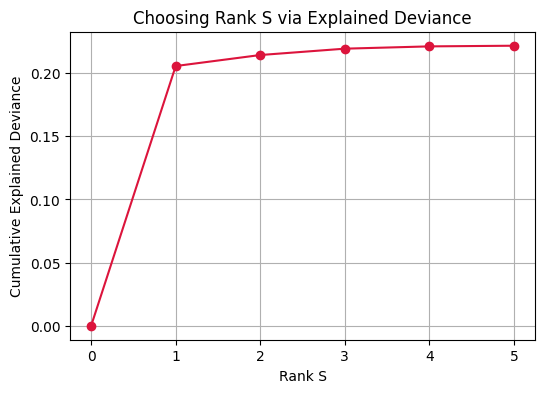

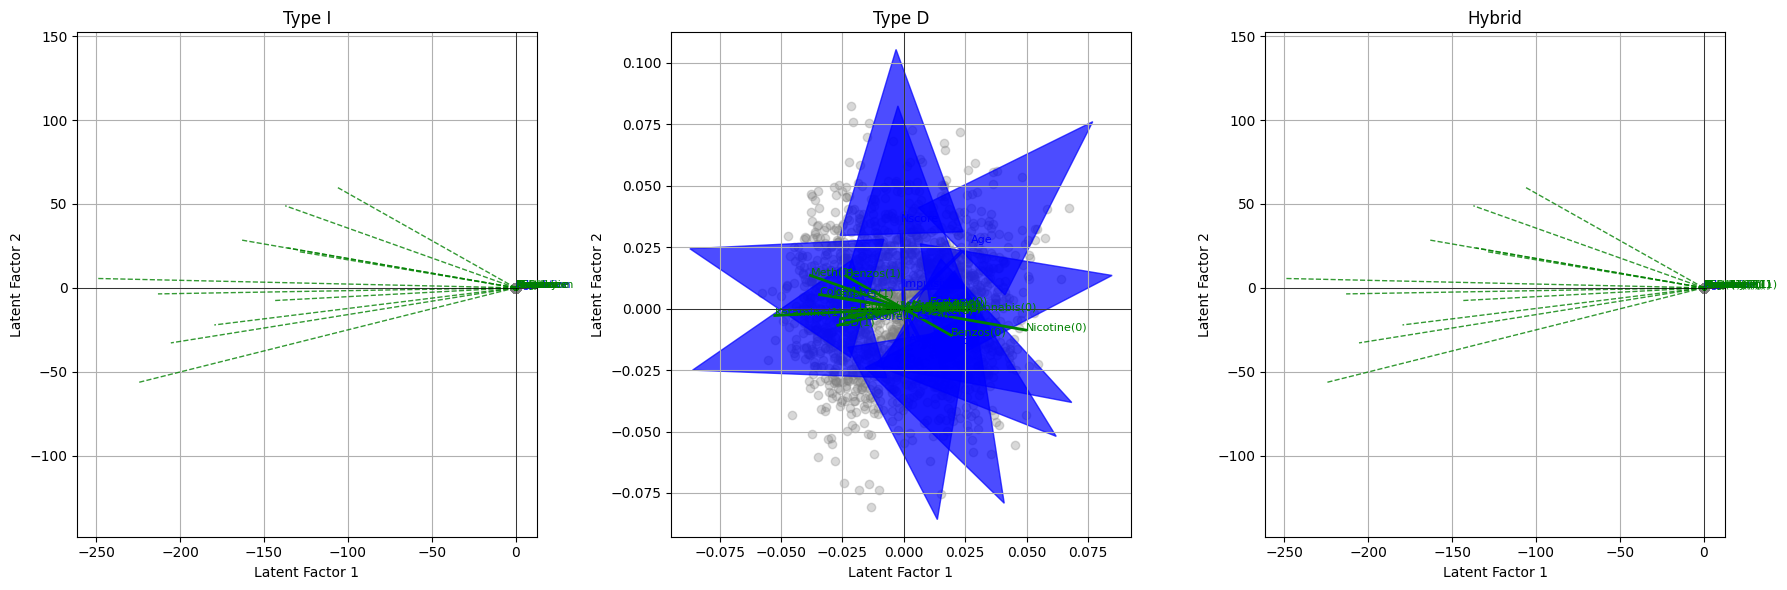

In [18]:
# ==============================================================
# Logistic Reduced Rank Regression (LRRR)
# Full Pipeline: Data → Model → Evaluation → Visualization
# ==============================================================
# Author: [Your Name]
# Based on the algorithm described in de Rooij & Heiser (2023)
# ==============================================================
# You can run this notebook end-to-end to reproduce the results
# on the UCI Drug Consumption dataset.
# ==============================================================

# --------------------------------------------------------------
# 1️⃣ Imports
# --------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid
from numpy.linalg import svd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# --------------------------------------------------------------
# 2️⃣ Load and preprocess the Drug Consumption dataset
# --------------------------------------------------------------
# Dataset source:
# https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data

cols = ['ID','Age','Gender','Education','Country','Ethnicity',
        'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS'] + \
       ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc','Coke',
        'Crack','Ecstasy','Heroin','Ketamine','Legalh','LSD','Meth','Mushroom',
        'Nicotine','Semer','VSA']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"
df = pd.read_csv(url, header=None, names=cols)

print("Raw dataset shape:", df.shape)

# Convert categorical CL0–CL6 to binary (CL3–CL6 → 1, others → 0)
def to_binary(val):
    return 1 if val in ['CL3','CL4','CL5','CL6'] else 0

drug_cols = ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc','Coke',
             'Crack','Ecstasy','Heroin','Ketamine','Legalh','LSD','Meth','Mushroom',
             'Nicotine','Semer','VSA']
for col in drug_cols:
    df[col] = df[col].apply(to_binary)

# Define predictor and response columns
predictor_cols = ['Age','Gender','Education','Nscore','Escore','Oscore','Ascore',
                  'Cscore','Impulsive','SS']
X = df[predictor_cols].to_numpy(float)
Y = df[drug_cols].to_numpy(float)

# Filter outcomes with moderate prevalence (0.1–0.9)
col_means = Y.mean(axis=0)
mask = (col_means >= 0.1) & (col_means <= 0.9)
Y = Y[:, mask]
selected_drugs = [drug_cols[i] for i, keep in enumerate(mask) if keep]

# Standardize predictors (zero mean, unit variance)
X = StandardScaler().fit_transform(X)
print(f"Predictors shape {X.shape}, Responses shape {Y.shape}")
print("Selected drug outcomes:", selected_drugs)

# --------------------------------------------------------------
# 3️⃣ Define helper functions (deviance, SVD update, etc.)
# --------------------------------------------------------------

def deviance(Y, P):
    """Compute logistic deviance (−2 log-likelihood)."""
    eps = 1e-10
    return -2 * np.sum(Y * np.log(P + eps) + (1 - Y) * np.log(1 - P + eps))

# --------------------------------------------------------------
# 4️⃣ Majorization–Minimization algorithm
# --------------------------------------------------------------
def mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-6, verbose=True):
    """
    Logistic Reduced Rank Regression via Majorization–Minimization (MM).
    X : predictor matrix (N×P)
    Y : binary response matrix (N×R)
    S : rank (latent dimension)
    Returns dict with B, V, m, fitted Pi, and deviance trace.
    """
    N, P = X.shape
    R = Y.shape[1]

    # Initialization: small random loadings, zero intercepts
    np.random.seed(42)
    B = np.random.normal(0, 0.1, (P, S))
    V = np.random.normal(0, 0.1, (R, S))
    m = np.zeros(R)

    eigvals, eigvecs = np.linalg.eigh(X.T @ X)
    inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    dev_trace = []
    for it in range(max_iter):
        # Step 1: Compute linear predictor & probabilities
        Eta = np.outer(np.ones(N), m) + X @ B @ V.T
        Pi = sigmoid(Eta)

        # Step 2: Working response (quadratic surrogate)
        Z = Eta + 4 * (Y - Pi)

        # Step 3: Update intercepts (column means)
        m = np.mean(Z - X @ B @ V.T, axis=0)

        # Step 4: Center working responses
        A = Z - np.outer(np.ones(N), m)

        # Step 5: Whitened cross-covariance & SVD
        M = inv_sqrt @ X.T @ A
        U_M, svals, Vt_M = svd(M, full_matrices=False)
        U_S = U_M[:, :S]
        Sigma_S = np.diag(svals[:S])
        Q_S = Vt_M.T[:, :S]

        # Step 6: Parameter updates
        B = inv_sqrt @ U_S
        V = Q_S @ Sigma_S

        # Step 7: Deviance + convergence check
        Eta_new = np.outer(np.ones(N), m) + X @ B @ V.T
        Pi_new = sigmoid(Eta_new)
        dev = deviance(Y, Pi_new)
        dev_trace.append(dev)

        if verbose:
            print(f"Iter {it+1:2d}: Deviance = {dev:.6f}")

        if it > 0 and abs(dev_trace[-2] - dev_trace[-1]) < tol:
            print("Converged after", it+1, "iterations.")
            break

    return {"B": B, "V": V, "m": m, "Pi": Pi_new, "deviance": dev_trace}

# --------------------------------------------------------------
# 5️⃣ Fit model (S=2) on the drug dataset
# --------------------------------------------------------------
results_drugs = mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-6)

plt.figure(figsize=(6,4))
plt.plot(results_drugs["deviance"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Deviance")
plt.title("Deviance Convergence — MM Algorithm (Drug Data)")
plt.grid(True)
plt.show()

B = results_drugs["B"]
V = results_drugs["V"]
m = results_drugs["m"]
U = X @ B
print("Final shapes: B", B.shape, "V", V.shape)

# --------------------------------------------------------------
# 6️⃣ Quality of Representation (QoR) per response
# --------------------------------------------------------------
def quality_of_representation(Y, Pi):
    """Explained deviance (per response)."""
    eps = 1e-10
    QoR = []
    for r in range(Y.shape[1]):
        y = Y[:, r]
        pi = Pi[:, r]
        p_null = np.mean(y)
        D_null = -2 * np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))
        D_model = -2 * np.sum(y * np.log(pi + eps) + (1 - y) * np.log(1 - pi + eps))
        QoR.append(1 - D_model / D_null)
    return np.array(QoR)

QoR_values = quality_of_representation(Y, results_drugs["Pi"])

plt.figure(figsize=(8,4))
plt.bar(selected_drugs, QoR_values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quality of Representation (QoR)")
plt.title("Explained Deviance per Drug Outcome (Rank S=2)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --------------------------------------------------------------
# 7️⃣ Cumulative Explained Deviance vs. Rank (Model Selection)
# --------------------------------------------------------------
def explained_deviance_curve(X, Y, max_S=5, max_iter=40):
    eps = 1e-10
    p_null = Y.mean(axis=0)
    D_null = -2 * np.sum(Y * np.log(p_null + eps) + (1 - Y) * np.log(1 - p_null + eps))
    explained = []
    for S in range(max_S+1):
        if S == 0:
            D_model = D_null
        else:
            res = mm_logistic_rrr(X, Y, S=S, max_iter=max_iter, tol=1e-6, verbose=False)
            D_model = res["deviance"][-1]
        explained.append(1 - D_model / D_null)
        print(f"S={S}: Explained deviance={explained[-1]:.4f}")
    return np.array(explained)

curve = explained_deviance_curve(X, Y, max_S=5)
plt.figure(figsize=(6,4))
plt.plot(range(len(curve)), curve, marker='o', color='crimson')
plt.xlabel("Rank S")
plt.ylabel("Cumulative Explained Deviance")
plt.title("Choosing Rank S via Explained Deviance")
plt.grid(True)
plt.show()

# --------------------------------------------------------------
# 8️⃣ Multi-panel Triplot Visualization (Type I, D, Hybrid)
# --------------------------------------------------------------
def multi_triplot(U, B, V, m, predictor_names, response_names,
                  prob_levels=[0.1, 0.5, 0.9]):
    """Side-by-side comparison of Type I, Type D, and Hybrid triplots."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax_i, triplot_type in enumerate(["Type I", "Type D", "Hybrid"]):
        ax = axes[ax_i]
        # Objects
        ax.scatter(U[:,0], U[:,1], color='gray', alpha=0.3, label='Individuals')

        # Predictors
        for j, name in enumerate(predictor_names):
            ax.arrow(0, 0, B[j,0]*2, B[j,1]*2, color='blue', head_width=0.05, alpha=0.7)
            ax.text(B[j,0]*2.3, B[j,1]*2.3, name, color='blue', fontsize=8)

        # Responses (switch based on triplot type)
        for r, name in enumerate(response_names):
            v = V[r,:]
            v_norm2 = np.dot(v, v)
            if triplot_type in ["Type I", "Hybrid"]:
                line_end = v * 3
                ax.plot([0, line_end[0]], [0, line_end[1]], 'g--', lw=1, alpha=0.8)
                for p in prob_levels:
                    t = (np.log(p/(1-p)) - m[r]) / v_norm2
                    tick = t * v
                    ax.plot(tick[0], tick[1], 'go', markersize=2)
                    if p == 0.5 and triplot_type == "Type I":
                        ax.text(tick[0], tick[1], name, color='green', fontsize=8)
            if triplot_type in ["Type D", "Hybrid"]:
                w_yes = (-m[r] / v_norm2) * v
                w_no = w_yes - (2 / v_norm2) * v
                ax.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], 'g-', lw=2)
                if triplot_type == "Type D":
                    ax.text(w_yes[0], w_yes[1], f"{name}(1)", color='green', fontsize=8)
                    ax.text(w_no[0], w_no[1], f"{name}(0)", color='green', fontsize=8)
                elif triplot_type == "Hybrid":
                    ax.text(w_yes[0], w_yes[1], f"{name}(1)", color='green', fontsize=8)

        ax.axhline(0, color='black', lw=0.5)
        ax.axvline(0, color='black', lw=0.5)
        ax.set_title(triplot_type)
        ax.set_xlabel("Latent Factor 1")
        ax.set_ylabel("Latent Factor 2")
        ax.grid(True)
        ax.axis("equal")

    plt.tight_layout()
    plt.show()

# Run the visualization
multi_triplot(U, B, V, m, predictor_cols, selected_drugs)


In [20]:
# ==============================================================
# Hybrid Triplot with probability tick labels (publication-ready)
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt

def hybrid_triplot_with_labels(U, B, V, m, predictor_names, response_names,
                               prob_levels=[0.1, 0.25, 0.5, 0.75, 0.9],
                               axis_length=3.0,
                               tick_marker='o',
                               tick_color='green',
                               tick_size=4,
                               label_offset=0.12):
    """
    Hybrid triplot: combines Type I ticks + Type D endpoints and LABELS the
    probability ticks (e.g. 0.1, 0.5, 0.9).
    
    Parameters
    ----------
    U : (N x S) array
        Object coordinates (U = X @ B). Only S=2 supported for plotting.
    B : (P x S) array
        Predictor loadings.
    V : (R x S) array
        Response loadings.
    m : (R,) array
        Intercepts per response.
    predictor_names : list[str]
        Names for predictor arrows (length P).
    response_names : list[str]
        Names for response arrows (length R).
    prob_levels : list[float]
        Probability levels to show and label along each response axis.
    axis_length : float
        How far to draw the response axis in the positive direction.
    label_offset : float
        Perpendicular offset distance for tick labels to reduce overlap.
    """
    assert U.shape[1] == 2 and B.shape[1] == 2 and V.shape[1] == 2, "Only 2-D latent space is supported for plotting."

    fig, ax = plt.subplots(figsize=(8,8))

    # Plot objects (individuals)
    ax.scatter(U[:,0], U[:,1], color='gray', alpha=0.35, label='Individuals', s=40)

    # Plot predictor arrows (blue)
    for j, name in enumerate(predictor_names):
        bx, by = B[j, 0], B[j, 1]
        ax.arrow(0, 0, bx*2, by*2, color='blue', head_width=0.05, length_includes_head=True, alpha=0.8)
        ax.text(bx*2.3, by*2.3, name, color='blue', fontsize=9)

    # For each response, draw axis, ticks, labels and Type D endpoints
    for r, name in enumerate(response_names):
        v = V[r, :]          # response loading vector (length 2)
        v_norm2 = np.dot(v, v)
        if v_norm2 == 0:
            continue

        # 1) Dotted axis line (Type I style)
        v_line = v / np.linalg.norm(v) * axis_length
        ax.plot([0, v_line[0]], [0, v_line[1]], linestyle='--', color='green', linewidth=1, alpha=0.8)

        # 2) Probability ticks and labels (Type I ticks)
        #    For each probability p, compute scalar t so that logit(p) = m_r + t * (v^T v)
        #    Thus t = (logit(p) - m_r) / (v^T v), and the tick point = t * v.
        for p in prob_levels:
            # avoid invalid probabilities (0 or 1)
            if p <= 0 or p >= 1:
                continue
            logit_p = np.log(p / (1 - p))
            t = (logit_p - m[r]) / v_norm2
            tick_point = t * v    # coordinates (x,y)

            # draw tick marker
            ax.plot(tick_point[0], tick_point[1], tick_marker, color=tick_color, markersize=tick_size)

            # label the tick slightly offset perpendicular to v to avoid overlap
            # perpendicular direction (rotate v by 90 degrees)
            perp = np.array([-v[1], v[0]])
            perp = perp / (np.linalg.norm(perp) + 1e-12)  # unit perpendicular
            # choose small offset scaled by label_offset
            label_pos = tick_point + perp * label_offset
            # For the 0.5 tick we might want the name rather than number; else numeric label
            label_text = f"{p:.2f}" if (abs(p - 0.5) > 1e-8) else f"{p:.2f}"
            ax.text(label_pos[0], label_pos[1], label_text, color=tick_color, fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.5))

        # 3) Type D endpoints (No / Yes) as a small solid segment on the same axis
        #    Position of "yes" endpoint: w_yes = (-m_r / v_norm2) * v
        #    Position of "no"  endpoint:  w_no  = w_yes - (2 / v_norm2) * v
        w_yes = (-m[r] / v_norm2) * v
        w_no = w_yes - (2.0 / v_norm2) * v
        ax.plot([w_no[0], w_yes[0]], [w_no[1], w_yes[1]], '-', color='green', linewidth=2, alpha=0.9)
        # label endpoints, pushed slightly along perpendicular to avoid overlapping the segment
        perp = np.array([-v[1], v[0]])
        perp = perp / (np.linalg.norm(perp) + 1e-12)
        ax.text(w_yes[0] + perp[0]*label_offset, w_yes[1] + perp[1]*label_offset, f"{name}(1)", color='green', fontsize=8)
        ax.text(w_no[0]  + perp[0]*label_offset, w_no[1]  + perp[1]*label_offset, f"{name}(0)", color='green', fontsize=8)

    # Final polishing
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel("Latent Factor 1")
    ax.set_ylabel("Latent Factor 2")
    ax.set_title("Hybrid Triplot (with probability tick labels)")
    ax.grid(True)
    ax.axis('equal')

    # legend (custom)
    ax.scatter([], [], color='gray', alpha=0.35, label='Individuals')
    ax.plot([], [], 'g--', label='Response axes (Type I)')
    ax.plot([], [], 'g-', linewidth=2, label='Category segment (Type D)')
    ax.scatter([], [], color=tick_color, label='Probability ticks')
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage (after running model):
# -------------------------
# U = X @ B
# hybrid_triplot_with_labels(U, B, V, m, predictor_cols, selected_drugs)


In [21]:
results_drugs = mm_logistic_rrr(X, Y, S=2, max_iter=50, tol=1e-6)


Iter  1: Deviance = 18972.046326
Iter  2: Deviance = 18416.364901
Iter  3: Deviance = 18222.345501
Iter  4: Deviance = 18134.596801
Iter  5: Deviance = 18089.375875
Iter  6: Deviance = 18064.082576
Iter  7: Deviance = 18049.094062
Iter  8: Deviance = 18039.814274
Iter  9: Deviance = 18033.865602
Iter 10: Deviance = 18029.942515
Iter 11: Deviance = 18027.293643
Iter 12: Deviance = 18025.469528
Iter 13: Deviance = 18024.192383
Iter 14: Deviance = 18023.285621
Iter 15: Deviance = 18022.634193
Iter 16: Deviance = 18022.161516
Iter 17: Deviance = 18021.815638
Iter 18: Deviance = 18021.560731
Iter 19: Deviance = 18021.371726
Iter 20: Deviance = 18021.230859
Iter 21: Deviance = 18021.125409
Iter 22: Deviance = 18021.046173
Iter 23: Deviance = 18020.986442
Iter 24: Deviance = 18020.941290
Iter 25: Deviance = 18020.907077
Iter 26: Deviance = 18020.881100
Iter 27: Deviance = 18020.861340
Iter 28: Deviance = 18020.846287
Iter 29: Deviance = 18020.834804
Iter 30: Deviance = 18020.826034
Iter 31: D

In [22]:
B = results_drugs["B"]
V = results_drugs["V"]
m = results_drugs["m"]
U = X @ B



Plotting hybrid triplot (this may take a few seconds)...


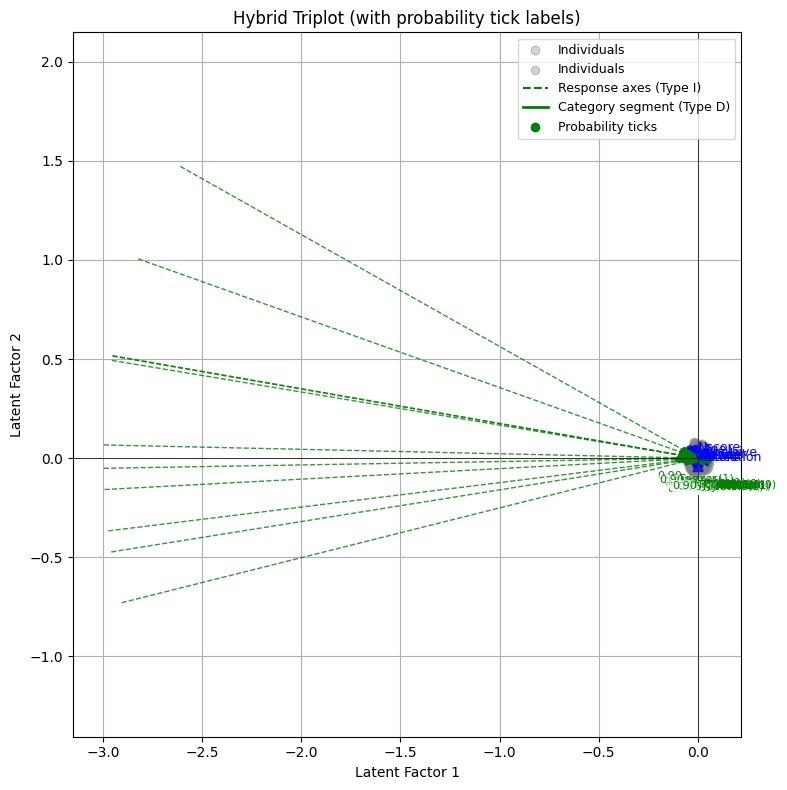

In [23]:
# --------------------------------------------------------------
# Run the hybrid triplot with probability labels
# --------------------------------------------------------------

U = X @ B  # latent coordinates
print("Plotting hybrid triplot (this may take a few seconds)...")

hybrid_triplot_with_labels(
    U,              # object coordinates
    B,              # predictor loadings
    V,              # response loadings
    m,              # intercepts
    predictor_cols, # predictor variable names
    selected_drugs, # selected outcome names
    prob_levels=[0.1, 0.25, 0.5, 0.75, 0.9], # probability ticks
    label_offset=0.15                          # spacing for labels
)



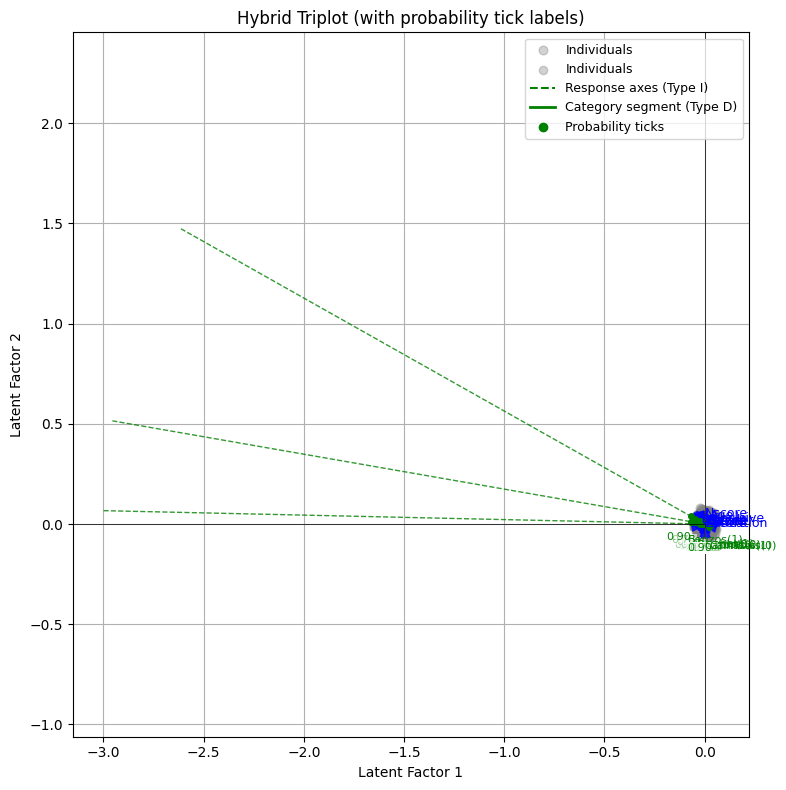

In [25]:
subset_drugs = selected_drugs[:3]  # first 8 drugs only
hybrid_triplot_with_labels(U, B, V, m, predictor_cols, subset_drugs)
